# Figure 2 data and visualization
Gaussian impulse simulation data, initial/optimized designs, and CNN predictions exported from the original co-optimization notebooks.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data"

plt.rcParams.update({
    "axes.grid": False,
    "figure.figsize": (7, 4),
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
})
COLORS = ["#cc3f40", "#bdccd4", "#0b2456", "#2980b9", "#00a043"]


In [2]:
data = np.load(DATA_DIR / 'figure2_gaussian_impulse.npz')
print('keys:', data.files)
print('input_data', data['input_data'].shape, 'output_data', data['output_data'].shape)
print('optimized design idx:', int(data['design_idx']))
print('mean prediction error initial/optimized:', data['prediction_error_initial'].mean(), data['prediction_error_optimized'].mean())

keys: ['time', 'input_data', 'output_data', 'test_indices', 'initial_design', 'optimized_design', 'design_idx', 'loss_record', 'test_input_initial', 'test_force_initial', 'test_pred_initial', 'test_input_optimized', 'test_force_optimized', 'test_pred_optimized', 'train_input_optimized', 'train_force_optimized', 'prediction_error_initial', 'prediction_error_optimized']
input_data (300, 200, 3) output_data (300, 200, 2)
optimized design idx: 95
mean prediction error initial/optimized: 8.585986 10.120841


In [3]:
def plot_force_dataset(time, force, title):
    fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharex=True, constrained_layout=True)
    labels = ["Left panel", "Right panel"]
    for ch, ax in enumerate(axes):
        for i in range(min(40, force.shape[0])):
            ax.plot(time, -force[i, :, ch], color=COLORS[ch], alpha=0.25, linewidth=0.7)
        ax.set_title(labels[ch])
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Force")
    fig.suptitle(title)
    return fig


def plot_prediction_examples(time, true_init, pred_init, true_opt, pred_opt, sample=0):
    fig, axes = plt.subplots(2, 2, figsize=(8, 4.8), sharex=True, constrained_layout=True)
    for ch in range(2):
        axes[0, ch].plot(time, -true_init[sample, :, ch], color=COLORS[0], label="True")
        axes[0, ch].plot(time, -pred_init[sample, :, ch], color=COLORS[1], label="CNN")
        axes[0, ch].set_title(["Initial, left", "Initial, right"][ch])
        axes[1, ch].plot(time, -true_opt[sample, :, ch], color=COLORS[0], label="True")
        axes[1, ch].plot(time, -pred_opt[sample, :, ch], color=COLORS[2], label="CNN optimized")
        axes[1, ch].set_title(["Optimized, left", "Optimized, right"][ch])
        axes[1, ch].set_xlabel("Time [s]")
    for ax in axes.ravel():
        ax.set_ylabel("Force")
        ax.legend(loc="upper right")
    return fig


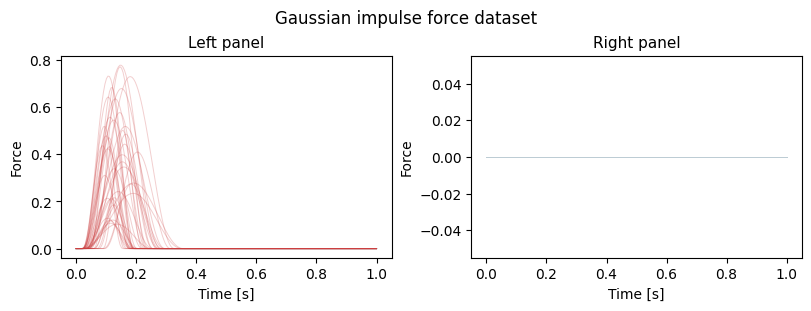

In [4]:
plot_force_dataset(data['time'], data['output_data'], 'Gaussian impulse force dataset')
plt.show()

In [5]:
def unpack_design(design, n1_blocks=5, n2_blocks=4):
    h_len = (n1_blocks + 1) * n2_blocks * 2
    horizontal = design[:h_len].reshape((n1_blocks + 1, n2_blocks, 2))
    vertical = design[h_len:].reshape((n1_blocks, n2_blocks + 1, 2))
    return horizontal, vertical


def plot_design_pair(initial_design, optimized_design, optimized_label):
    from blockymetamaterials.geometry import QuadGeometry_InputSource
    from blockymetamaterials.plotting_input import plot_geometry
    import jax.numpy as jnp

    n1_blocks, n2_blocks, n_source = 5, 4, 2
    spacing = 15.0 + 0.075 * 15.0
    hinge_length = 0.075 * 15.0
    geometry = QuadGeometry_InputSource(n1_blocks, n2_blocks, spacing=spacing, bond_length=hinge_length, n_source=n_source)
    block_centroids, centroid_node_vectors, bond_connectivity, _ = geometry.get_parametrization()
    bonds = bond_connectivity()

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.4), constrained_layout=True)
    for ax, design, title, color in zip(
        axes,
        [initial_design, optimized_design],
        ["Initial design", optimized_label],
        ["#2c3e50", "#0b2456"],
    ):
        h, v = unpack_design(design, n1_blocks, n2_blocks)
        h, v = jnp.asarray(h), jnp.asarray(v)
        plot_geometry(
            block_centroids=block_centroids(h, v),
            centroid_node_vectors=centroid_node_vectors(h, v),
            bond_connectivity=bonds,
            ax=ax,
            color=color,
        )
        ax.set_aspect("equal")
        ax.axis("off")
        ax.set_title(title)
    return fig


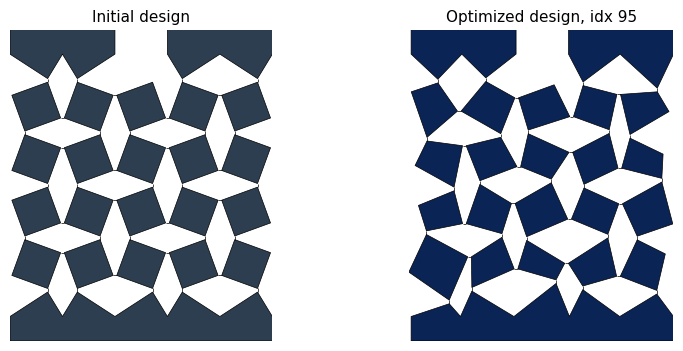

In [6]:
plot_design_pair(data['initial_design'], data['optimized_design'], f"Optimized design, idx {int(data['design_idx'])}")
plt.show()

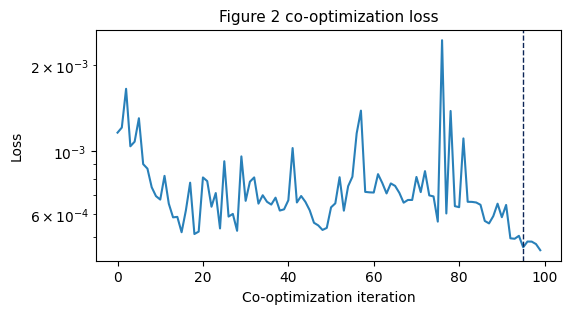

In [7]:
plt.figure(figsize=(6, 3))
plt.semilogy(data['loss_record'], color=COLORS[3])
plt.axvline(int(data['design_idx']), color=COLORS[2], linestyle='--', linewidth=1)
plt.xlabel('Co-optimization iteration')
plt.ylabel('Loss')
plt.title('Figure 2 co-optimization loss')
plt.show()

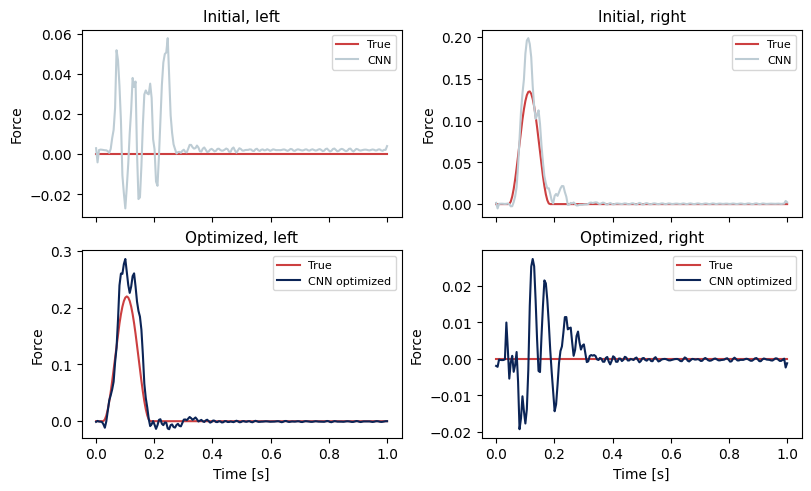

In [8]:
plot_prediction_examples(data['time'], data['test_force_initial'], data['test_pred_initial'], data['test_force_optimized'], data['test_pred_optimized'], sample=0)
plt.show()